# German Traffic Sign Recognition Benchmark

In [1]:
import cv2 # Resim okumak için
import pandas as pd # dosya okumak için
from sklearn.model_selection import train_test_split
import numpy as np
import os
from keras.models import Sequential
from keras.layers import Conv2D,Dense,Flatten,Input,MaxPooling2D,Dropout,BatchNormalization,Reshape
from keras.utils import to_categorical

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
train_df=pd.read_csv("Train.csv")

In [4]:
images=[]
labels=[]

In [5]:
IMG_HEIGHT = 32
IMG_WIDTH = 32

In [6]:
for _, row in train_df.iterrows():
    img_path = row["Path"]
    img = cv2.imread(img_path)
    if img is not None:
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
        images.append(img)
        labels.append(row["ClassId"])  

In [11]:
X = np.array(images, dtype="float32") / 255.0
y = to_categorical(np.array(labels), num_classes=43)

In [12]:
x_train, x_val, y_train, y_val = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [13]:
model=Sequential()
model.add(Input(shape=(32, 32, 3)))
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu',padding="same"))
model.add(BatchNormalization())
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu',padding="same"))
model.add(BatchNormalization())
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128, activation='relu'))  
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(43, activation='softmax'))  # Ensure 2 classes for binary classification

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 30, 30, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 30, 30, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 15, 15, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 15, 15, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 13, 13, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 13, 13, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2304)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         295,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 43)                  │           5,547 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 367,435 (1.40 MB)

 Trainable params: 366,795 (1.40 MB)

 Non-trainable params: 640 (2.50 KB)

In [14]:
history = model.fit(x_train,y_train,batch_size=64,epochs=20,validation_data=(x_val, y_val), verbose=1)

Epoch 1/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 117s 224ms/step - accuracy: 0.7463 - loss: 0.9874 - val_accuracy: 0.8243 - val_loss: 0.6764
Epoch 2/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 114s 232ms/step - accuracy: 0.9667 - loss: 0.1378 - val_accuracy: 0.9935 - val_loss: 0.0314
Epoch 3/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 141s 231ms/step - accuracy: 0.9818 - loss: 0.0733 - val_accuracy: 0.9857 - val_loss: 0.0492
Epoch 4/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 142s 231ms/step - accuracy: 0.9866 - loss: 0.0526 - val_accuracy: 0.9939 - val_loss: 0.0269
Epoch 5/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 147s 240ms/step - accuracy: 0.9883 - loss: 0.0414 - val_accuracy: 0.9982 - val_loss: 0.0085
Epoch 6/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 111s 226ms/step - accuracy: 0.9926 - loss: 0.0264 - val_accuracy: 0.9971 - val_loss: 0.0124
Epoch 7/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 108s 219ms/step - accuracy: 0.9924 - loss: 0.0247 - val_accuracy: 0.9964 - val_loss: 0.0114
Epoch 8/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 101s 206ms/step - accuracy: 0.9946 -

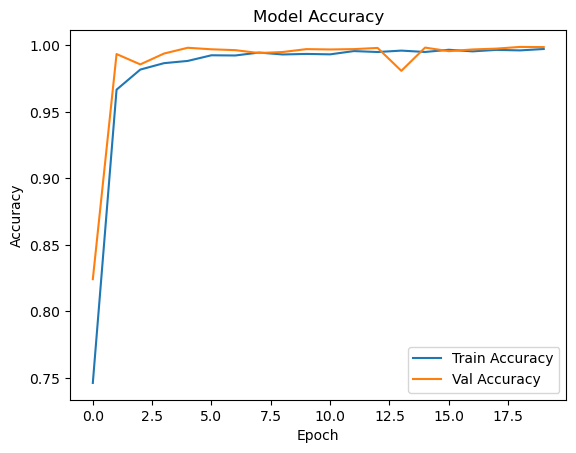

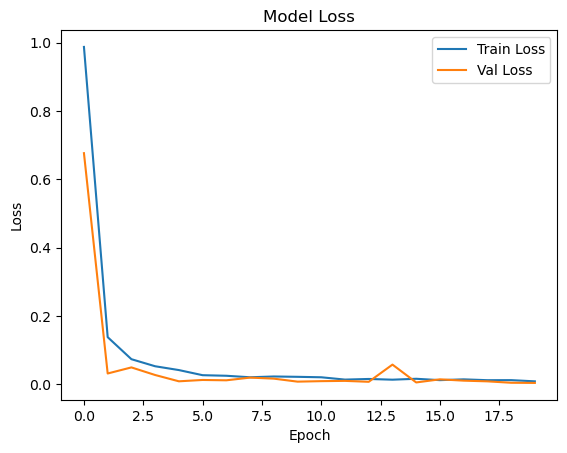

In [16]:
import matplotlib.pyplot as plt

# Accuracy Plot
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss Plot
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

246/246 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step


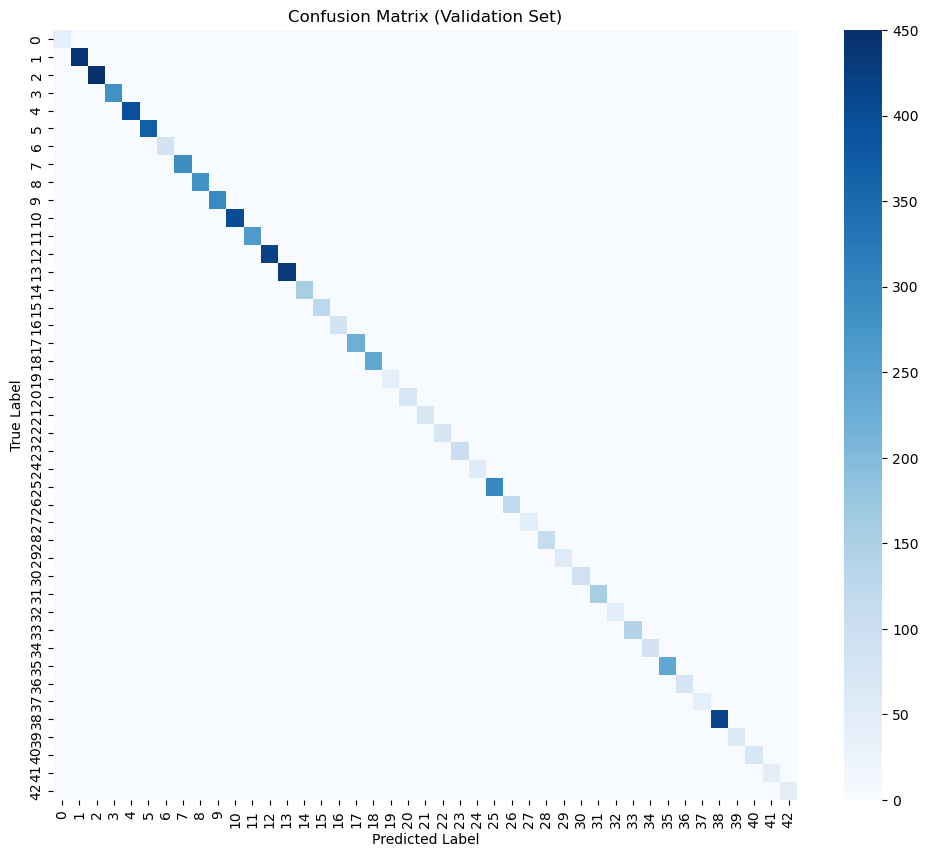

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        42
           1       1.00      1.00      1.00       444
           2       1.00      1.00      1.00       450
           3       1.00      1.00      1.00       282
           4       1.00      1.00      1.00       396
           5       1.00      0.99      0.99       372
           6       1.00      1.00      1.00        84
           7       1.00      1.00      1.00       288
           8       1.00      1.00      1.00       282
           9       1.00      1.00      1.00       294
          10       1.00      1.00      1.00       402
          11       1.00      1.00      1.00       264
          12       1.00      1.00      1.00       420
          13       1.00      1.00      1.00       432
          14       1.00      1.00      1.00       156
          15       1.00      1.00      1.00       126
          16       0.99      1.00      0.99        84
          17       1.00    

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
y_pred = model.predict(x_val)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_val, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix (Validation Set)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [18]:
from sklearn.metrics import accuracy_score, classification_report
test_df = pd.read_csv("Test.csv")


In [19]:
test_images = []
test_labels = []

In [20]:
IMG_HEIGHT = 32
IMG_WIDTH = 32

In [21]:
for _, row in test_df.iterrows():
  img_path = row["Path"]
  img = cv2.imread(img_path)

  if img is not None:
    img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
    test_images.append(img)
    test_labels.append(row["ClassId"])


In [22]:
X_test = np.array(test_images, dtype="float32") / 255.0
y_test = np.array(test_labels)


In [23]:
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

395/395 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step


In [24]:
accuracy = accuracy_score(y_test, y_pred)

In [25]:
accuracy

0.982818685669042

In [26]:
classification_report(y_test, y_pred)

'              precision    recall  f1-score   support\n\n           0       0.98      1.00      0.99        60\n           1       0.99      1.00      0.99       720\n           2       1.00      1.00      1.00       750\n           3       0.99      0.98      0.98       450\n           4       1.00      0.98      0.99       660\n           5       0.97      0.99      0.98       630\n           6       1.00      0.81      0.90       150\n           7       0.99      1.00      0.99       450\n           8       1.00      0.98      0.99       450\n           9       0.98      1.00      0.99       480\n          10       1.00      1.00      1.00       660\n          11       0.98      0.99      0.98       420\n          12       1.00      0.95      0.97       690\n          13       0.99      1.00      0.99       720\n          14       1.00      1.00      1.00       270\n          15       0.93      0.99      0.96       210\n          16       1.00      0.99      1.00       150\n       

In [27]:
from keras.models import load_model
model.save("traffic_sign_model.keras")